# 1. Keras 텍스트 전처리
    1. [수치 데이터로 변환] 텍스트 토큰화 및 정수 인코딩
    2. [같은 길이로 만들기] 패딩 (padding)

In [1]:
# tensorflow 설치 확인
import tensorflow
tensorflow.__version__

'2.10.0'

In [3]:
# 연습 샘플
texts = [
    "나는 학교에 간다",
    "너는 도서관에 간다",
    "그는 시장에 간다"
]
#texts = [ ["나", "학교", "가"], ["너", "도서관", "가"], ["그", "시장", "가"]]
texts

['나는 학교에 간다', '너는 도서관에 간다', '그는 시장에 간다']

## 1-1. 텍스트 데이터 Integer Encoding
- num_words = 사용할 단어 수 + 1

In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Tokenizer 객체 생성 (특징 벡터용 단어 수와 OOV 토큰 지정)
tokenizer = Tokenizer(num_words=5)

# 특징 집합 생성 및 정수 indexing
tokenizer.fit_on_texts(texts)
print("단어 인덱스:", tokenizer.word_index)

# 입력 텍스트 리스트의 integer encoding
encoded_texts = tokenizer.texts_to_sequences(texts)
print("정수 인코딩된 텍스트(시퀸스):", encoded_texts)


단어 인덱스: {'간다': 1, '나는': 2, '학교에': 3, '너는': 4, '도서관에': 5, '그는': 6, '시장에': 7}
정수 인코딩된 텍스트(시퀸스): [[2, 3, 1], [4, 1], [1]]


## 1-2. Padding : 입력 시퀀스의 길이를 동일하게 조정하기

In [13]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded_texts = pad_sequences(encoded_texts)
print("패딩된 시퀸스:")
print(padded_texts)

패딩된 시퀸스:
[[2 3 1]
 [0 4 1]
 [0 0 1]]


## 1-3. 정답 데이터 One-hot Encoding

In [17]:
label = [1, 0, 2, 5, 0, 2, 3]
from tensorflow.keras.utils import to_categorical

encoded_label = to_categorical(label)
encoded_label #정답 데이터를 미리 만들어준다(원-핫 벡터)


array([[0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.]], dtype=float32)

# 2. 텍스트 전처리를 위한 파라미터 결정하기
- Integer Encoding을 위한 단어(특징) 집합의 크기 정하기 (Tokenizer의 num_words)
- Padding을 위한 시퀀스 길이 정하기 (pad_sequences의 max_len) 

In [18]:
# 데이터 로딩 및 실습 데이터 추출
import pandas as pd
texts = list(pd.read_csv('./data/Korean_movie_reviews_2016.csv').review)
texts[:2]

['부산 행 때문 너무 기대하고 봤', '한국 좀비 영화 어색하지 않게 만들어졌 놀랍']

## 2-1. 단어 집합의 크기 정하기 (Tokenizer의 num_words)
등장 빈도수가 기준값(threshold)보다 적은 단어의 비중을 확인하여 정하기
1. corpus의 전체 단어 수 (total_cnt)와 전체 빈도수 (total_freq) 계산
2. threshold보다 빈도수가 적은 단어수 카운트 (rare_cnt)와 빈도수 (rare_freq) 계산
3. 희귀 단어의 비율(rare_cnt/total_cnt)과 희귀 등장 빈도 비율 계산(rare_freq/total_freq)
4. 희귀 단어를 뺀 단어 수 -> 단어 집합의 크기 산정

In [21]:
# Tokenizer로 단어-빈도 사전 생성

# Tokenizer 객체 생성 (특징 벡터용 단어 수와 OOV 토큰 지정)
test_tokenizer = Tokenizer()

# 특징 집합 생성 및 정수 indexing
test_tokenizer.fit_on_texts(texts)

In [34]:
# 등장 빈도수가 threshold회 미만인 단어들이 이 데이터에서 얼만큼의 비중을 차지하는지 확인
threshold = 3
total_cnt = len(test_tokenizer.word_index)  #단어 개수
rare_cnt = 0
total_freq = 0                              #빈도수
rare_freq = 0                               #희귀한 단어의 빈도수

# 단어, 빈도수를 받아서 빈도수가 threshold 작으면 rare_cnt, rare_freq에 update
for word, freq in test_tokenizer.word_counts.items():
    total_freq += freq
    if freq < threshold:
        rare_cnt += 1
        rare_freq += freq

print(f'전체 단어 : {total_cnt:,}개 {total_freq:,}번')
print(f'희귀 단어 : (등장빈도 {threshold}번 이하 :  {rare_cnt:,}개 {rare_freq:,}번')
print(f'희귀 단어 비율 : 단어수 {rare_cnt/total_cnt * 100:.2f}%, 빈도수 {rare_freq/total_freq*100:.2f}%')
print(f'희귀 단어를 뺀 단어수 : {total_cnt - rare_cnt:,}개 {(total_freq-rare_freq)/total_freq*100:.2f}%') # max_words


# test_tokenizer.word_counts.items()

전체 단어 : 52,011개 1,888,659번
희귀 단어 : (등장빈도 3번 이하 :  29,364개 35,871번
희귀 단어 비율 : 단어수 56.46%, 빈도수 1.90%
희귀 단어를 뺀 단어수 : 22,647개 98.10%


## 2-2. Padding 길이 정하기 (pad_sequences의 max_len)
1. 단어 길이 데이터로 DataFrame 생성
2. 분포 시각화 : DataFrame의 Histogram 시각화 (df.hist())
3. 단어 길이 통계 정보 확인 (df.describe())
4. 텍스트의 길이가 설정한 max_len 이하인 비율 계산

In [38]:
#단어 길이 데이터로 DataFrame 생성 (리스트 -> Dataframe)
import pandas as pd
len_list = [len(text.split()) for text in texts]
len_df = pd.DataFrame(len_list, columns=['length'])
len_df

,length
0,6
1,7
2,10
3,31
4,19
...,...
165379,14
165380,7
165381,8
165382,13


array([[<Axes: title={'center': 'length'}>]], dtype=object)

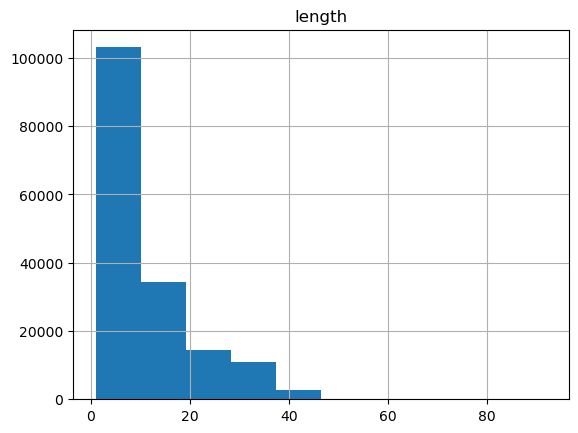

In [39]:
# 분포 시각화 : DataFrame의 Histogram 시각화 (df.hist())
len_df.hist()

In [40]:
#단어 길이 통계 정보 확인 (df.describe())
len_df.describe()

,length
count,165384.000000
mean,11.419841
std,9.117849
min,1.000000
25%,5.000000
50%,8.000000
75%,15.000000
max,92.000000


In [ ]:
#텍스트의 길이가 설정한 max_len 이하인 비율 계산
from mylib.my_utils import below_threshold_len 

max_len = 50
below_threshold_len(max_len,texts)

길이가 50 이하인 텍스트의 비율 : 99.99%
